In [71]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [72]:
KAGGLE_DS = "qingyi/wm811k-wafer-map"
PKL, ZIP = "data/LSWMD.pkl", "data/LSWMD.pkl.zip"

if os.path.exists(PKL):
    print(f"Found {PKL}, skipping download.")
else:
    import zipfile
    os.system(f"kaggle datasets download -d {KAGGLE_DS} -f LSWMD.pkl -p data")
    with zipfile.ZipFile(ZIP) as z:
        z.extractall("data")
    os.remove(ZIP)


import pickle


class _LegacyUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("pandas.indexes"):
            module = "pandas.core." + module[len("pandas."):]
        return super().find_class(module, name)


with open(PKL, "rb") as f:
    df = _LegacyUnpickler(f, encoding="latin1").load()

print(f"Loaded {len(df)} samples from {PKL}.")
print(f"Columns: {list(df.columns)}")
print(f"Data types: {df.dtypes}")


Found data/LSWMD.pkl, skipping download.
Loaded 811457 samples from data/LSWMD.pkl.
Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']
Data types: waferMap           object
dieSize           float64
lotName            object
waferIndex        float64
trianTestLabel     object
failureType        object
dtype: object


In [73]:
import random

sample_idx = random.sample(range(len(df)), 5)

for i in range(5):
    print(f"\nSample {i+1}:")
    idx = sample_idx[i]
    row = df.iloc[idx]
    for col in df.columns:
        print(f"{col}: type={type(row[col])}, shape={getattr(row[col], 'shape', None)}")


Sample 1:
waferMap: type=<class 'numpy.ndarray'>, shape=(52, 51)
dieSize: type=<class 'numpy.float64'>, shape=()
lotName: type=<class 'numpy.str_'>, shape=()
waferIndex: type=<class 'numpy.float64'>, shape=()
trianTestLabel: type=<class 'numpy.ndarray'>, shape=(0, 0)
failureType: type=<class 'numpy.ndarray'>, shape=(0, 0)

Sample 2:
waferMap: type=<class 'numpy.ndarray'>, shape=(52, 52)
dieSize: type=<class 'numpy.float64'>, shape=()
lotName: type=<class 'numpy.str_'>, shape=()
waferIndex: type=<class 'numpy.float64'>, shape=()
trianTestLabel: type=<class 'numpy.ndarray'>, shape=(0, 0)
failureType: type=<class 'numpy.ndarray'>, shape=(0, 0)

Sample 3:
waferMap: type=<class 'numpy.ndarray'>, shape=(39, 39)
dieSize: type=<class 'numpy.float64'>, shape=()
lotName: type=<class 'numpy.str_'>, shape=()
waferIndex: type=<class 'numpy.float64'>, shape=()
trianTestLabel: type=<class 'numpy.ndarray'>, shape=(0, 0)
failureType: type=<class 'numpy.ndarray'>, shape=(0, 0)

Sample 4:
waferMap: type

# Wafermap

waferMap shape: (41, 40), dtype: uint8 min: 0, max: 2, unique values: [0 1 2]


(np.float64(-0.5), np.float64(39.5), np.float64(40.5), np.float64(-0.5))

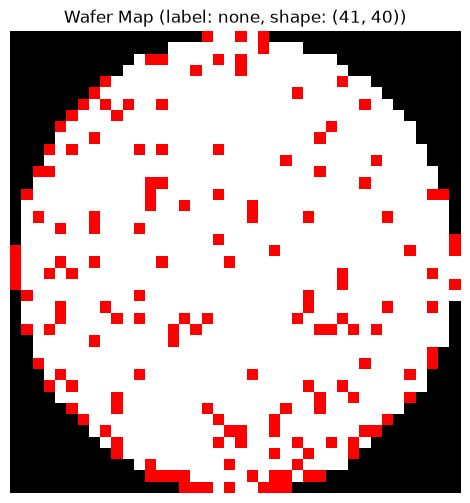

In [74]:

from matplotlib.colors import BoundaryNorm, ListedColormap

row = df.iloc[random.randint(0, len(df)-1)]

wm = np.array(row["waferMap"])

print(f"waferMap shape: {wm.shape}, dtype: {wm.dtype}", 
      f"min: {wm.min()}, max: {wm.max()}, unique values: {np.unique(wm)}")

WAFER_MAP_CMAP = ListedColormap([(0, 0, 0), (1, 1, 1), (1, 0, 0)])
WAFER_MAP_NORM = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], WAFER_MAP_CMAP.N)


def label_of(row):
    v = np.asarray(row["failureType"])
    return v.item() if v.size else "unlabeled"


fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(wm, cmap=WAFER_MAP_CMAP, norm=WAFER_MAP_NORM)
ax.set_title(f"Wafer Map (label: {label_of(row)}, shape: {wm.shape})")
ax.axis("off")

Wafer map shapes: min height=6, max height=300, min width=3, max width=205


Text(0.5, 1.0, 'Wafer Map Width Distribution')

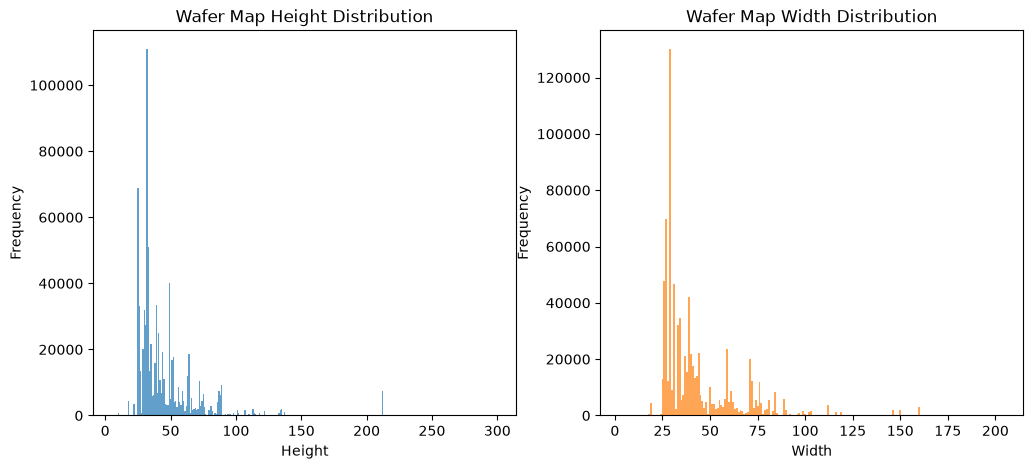

In [75]:
shapes = np.array([np.array(w).shape for w in df.loc[:, "waferMap"]])
h, w = shapes[:, 0], shapes[:, 1]

print(f"Wafer map shapes: min height={h.min()}, max height={h.max()}, min width={w.min()}, max width={w.max()}")
fig,ax = plt.subplots(1,2, figsize=(12, 5))

ax[0].hist(h, bins=np.arange(h.min(), h.max()+1)-0.5, color="C0", alpha=0.7)
ax[1].hist(w, bins=np.arange(w.min(), w.max()+1)-0.5, color="C1", alpha=0.7)

ax[0].set_xlabel("Height")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Wafer Map Height Distribution")

ax[1].set_xlabel("Width")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Wafer Map Width Distribution")

## Resizing

Downsampled wafer maps: 106175 / 811457 (13.08%)
Upsampled wafer maps: 672403 / 811457 (82.86%)
Mixed wafer maps: 32879 / 811457 (4.05%)


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

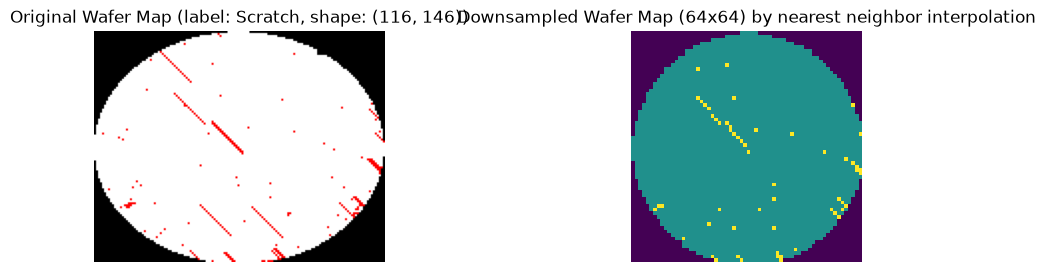

In [76]:

import cv2


h,w = shapes[:, 0], shapes[:, 1]
downsampled = (h >=64) & (w >= 64)
print(f"Downsampled wafer maps: {downsampled.sum()} / {len(df)} ({downsampled.mean()*100:.2f}%)")

upsampled = (h < 64) & (w < 64)
print(f"Upsampled wafer maps: {upsampled.sum()} / {len(df)} ({upsampled.mean()*100:.2f}%)")

mixed = ~(downsampled | upsampled)
print(f"Mixed wafer maps: {mixed.sum()} / {len(df)} ({mixed.mean()*100:.2f}%)")

def normalize_label(value):
    if isinstance(value,str):
        return value.strip().lower()
    arr = np.asarray(value)
    if arr.size == 0:
        return "unlabeled"
    return arr.item().strip().lower()
labels = df["failureType"].map(normalize_label)

scratch_example = np.flatnonzero((labels == "scratch").values)
scratch_size = np.array([np.asarray(df["waferMap"].iloc[i]).shape for i in scratch_example])
downsample_example = scratch_example[(scratch_size[:, 0] >= 100) & (scratch_size[:, 1] >= 100)]

example_idx = random.choice(downsample_example)
fig, ax = plt.subplots(1,2,figsize=(12, 3))
ax[0].imshow(df.iloc[example_idx]["waferMap"], cmap=WAFER_MAP_CMAP, norm=WAFER_MAP_NORM)
ax[0].set_title(f"Original Wafer Map (label: {label_of(df.iloc[example_idx])}, shape: {df.iloc[example_idx]['waferMap'].shape})")
ax[0].axis("off")
ax[1].imshow(cv2.resize(df.iloc[example_idx]["waferMap"], (64, 64), interpolation=cv2.INTER_NEAREST))
ax[1].set_title(f"Downsampled Wafer Map (64x64) by nearest neighbor interpolation")
ax[1].axis("off")


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

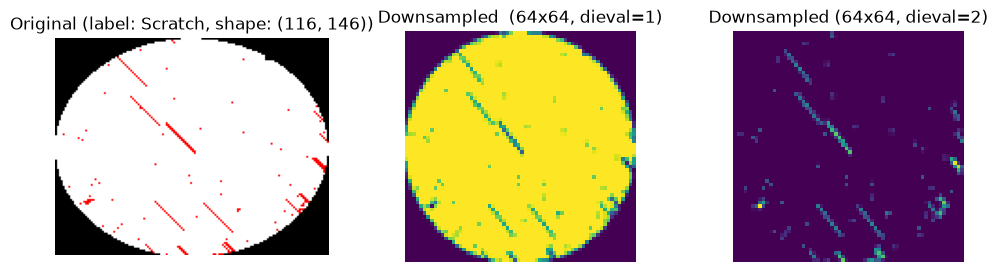

In [77]:
def resize_for_training(wafer_map, target_size=64):
    wm = np.array(wafer_map)
    out = np.empty((2, target_size, target_size), dtype=np.float32)

    shrinking = wm.shape[0] > target_size and wm.shape[1] > target_size
    interpolation = cv2.INTER_AREA if shrinking else cv2.INTER_LINEAR

    for i, dieval in enumerate((1,2)):
        mask = (wm == dieval).astype(np.float32)
        out[i] = cv2.resize(mask, (target_size, target_size), interpolation=interpolation)

    return out

fig, ax = plt.subplots(1, 3, figsize=(12, 3))

ax[0].imshow(df.iloc[example_idx]["waferMap"], cmap=WAFER_MAP_CMAP, norm=WAFER_MAP_NORM)
ax[0].set_title(f"Original (label: {label_of(df.iloc[example_idx])}, shape: {df.iloc[example_idx]['waferMap'].shape})")
ax[0].axis("off")

ax[1].imshow(resize_for_training(df.iloc[example_idx]["waferMap"])[0])
ax[1].set_title(f"Downsampled  (64x64, dieval=1)")
ax[1].axis("off")       

ax[2].imshow(resize_for_training(df.iloc[example_idx]["waferMap"])[1])
ax[2].set_title(f"Downsampled (64x64, dieval=2)")
ax[2].axis("off")

# DieSize

In [78]:
dies = df.loc[:,"dieSize"].astype(float).values
print(f"Die size: min={dies.min()}, max={dies.max()}, mean={dies.mean():.2f}, std={dies.std():.2f}")

dies_labelled = df.loc[df["failureType"].map(normalize_label) != "unlabeled", "dieSize"].astype(float).values
print(f"Die size (labelled): min={dies_labelled.min()}, max={dies_labelled.max()}, mean={dies_labelled.mean():.2f}, std={dies_labelled.std():.2f}")

Die size: min=3.0, max=48099.0, mean=1841.00, std=2254.99
Die size (labelled): min=3.0, max=22372.0, mean=1042.23, std=1032.57


              count         mean  median          std
failureType                                          
none         147431   921.378950   776.0   622.794114
edge-ring      9680  2601.081198  2085.0  2704.873628
edge-loc       5189  1171.150703   939.0   891.917222
center         4294   928.617606   515.0  1134.194816
loc            3593  1351.021431   938.0  1708.588198
scratch        1193  2010.430008  1167.0  2540.391540
random          866  1191.275982  1080.0  1058.791796
donut           555  1377.500901  1334.0   616.760719
near-full       149   821.456376   741.0   404.826497

Correlation ratio (eta): 0.3852
Eta squared: 0.1484


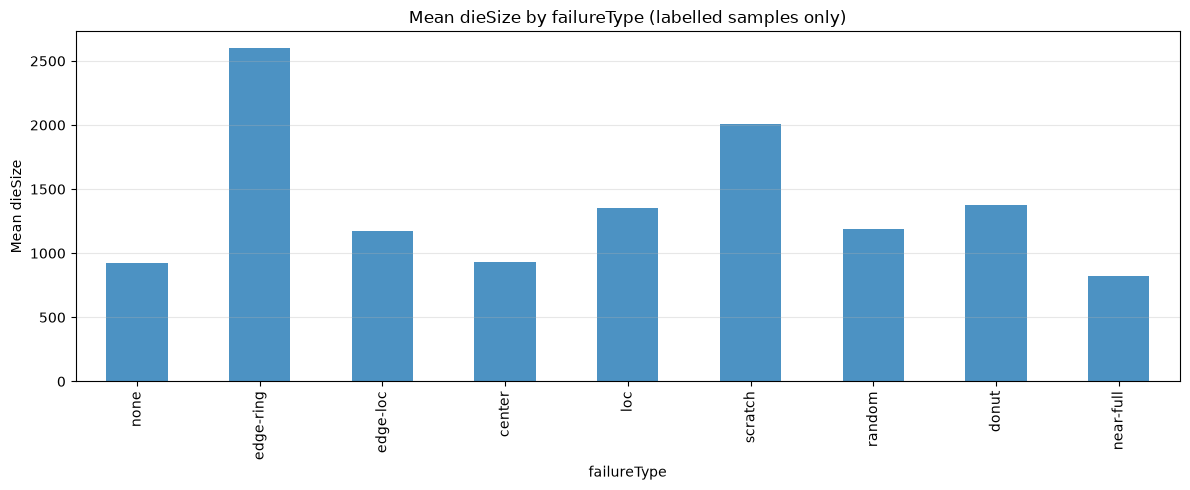

In [79]:
labelled_df = df.loc[df["failureType"].map(normalize_label) != "unlabeled", ["dieSize"]].copy()
labelled_df["failureType"] = labels[df["failureType"].map(normalize_label) != "unlabeled"].values
labelled_df["dieSize"] = labelled_df["dieSize"].astype(float)

summary = (
    labelled_df.groupby("failureType")["dieSize"]
    .agg(count="count", mean="mean", median="median", std="std")
    .sort_values("count", ascending=False)
)

print(summary.to_string())

y = labelled_df["dieSize"].to_numpy()
groups = [g["dieSize"].to_numpy() for _, g in labelled_df.groupby("failureType")]

grand_mean = y.mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = ((y - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total if ss_total else np.nan
eta = np.sqrt(eta_sq) if pd.notna(eta_sq) else np.nan

print(f"\nCorrelation ratio (eta): {eta:.4f}")
print(f"Eta squared: {eta_sq:.4f}")

fig, ax = plt.subplots(figsize=(12, 5))
summary["mean"].plot(kind="bar", ax=ax, color="C0", alpha=0.8)
ax.set_ylabel("Mean dieSize")
ax.set_title("Mean dieSize by failureType (labelled samples only)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

# LotName

In [80]:
unique_lots = pd.unique(df["lotName"].astype(str))   
n_lots = df["lotName"].nunique()                    
counts = df["lotName"].astype(str).value_counts()   
print(f"Number of unique lots: {n_lots}")
print(f"Lot counts:\n{counts.head(10)}")



Number of unique lots: 46293
Lot counts:
lotName
lot1     25
lot2     25
lot3     25
lot4     25
lot5     25
lot6     25
lot7     25
lot8     25
lot9     25
lot10    25
Name: count, dtype: int64


In [81]:
lot_label_df = pd.DataFrame({
    "lotName": df["lotName"].astype(str),
    "failureType": labels,
})

lot_label_df = lot_label_df[lot_label_df["failureType"].map(normalize_label) != ("unlabeled" or "none")]

lot_label_counts = (
    lot_label_df.groupby(["lotName", "failureType"])
    .size()
    .reset_index(name="count")
)

dominant_idx = lot_label_counts.groupby("lotName")["count"].idxmax()
dominant = lot_label_counts.loc[dominant_idx].rename(
    columns={"failureType": "dominant_failureType", "count": "dominant_count"}
)

lot_summary = (
    lot_label_counts.groupby("lotName")
    .agg(
        total_labeled=("count", "sum"),
        n_failure_types=("failureType", "nunique"),
    )
    .reset_index()
    .merge(dominant[["lotName", "dominant_failureType", "dominant_count"]], on="lotName", how="left")
)

lot_summary["dominant_share"] = lot_summary["dominant_count"] / lot_summary["total_labeled"]

print("Overall labeled samples:", len(lot_label_df))
print("Lots with labeled samples:", len(lot_summary))
print("Lots with a single failure type:", (lot_summary["n_failure_types"] == 1).sum())
print(f"Average dominant-label share per lot: {lot_summary['dominant_share'].mean():.3f}")

print("\nTop 10 most consistent lots:")
print(
    lot_summary.sort_values(["dominant_share", "total_labeled"], ascending=[False, False])
    .head(10)
    .to_string(index=False)
)

print("\nLots with mixed failure types (top 10):")
print(
    lot_summary[lot_summary["n_failure_types"] > 1]
    .sort_values(["n_failure_types", "total_labeled"], ascending=[False, False])
    .head(10)
    .to_string(index=False)
)

Overall labeled samples: 172950
Lots with labeled samples: 10762
Lots with a single failure type: 6558
Average dominant-label share per lot: 0.957

Top 10 most consistent lots:
 lotName  total_labeled  n_failure_types dominant_failureType  dominant_count  dominant_share
lot10009             25                1            edge-ring              25             1.0
lot10050             25                1            edge-ring              25             1.0
lot10051             25                1            edge-ring              25             1.0
lot10182             25                1            edge-ring              25             1.0
lot10183             25                1            edge-ring              25             1.0
lot10184             25                1            edge-ring              25             1.0
lot10186             25                1            edge-ring              25             1.0
lot10187             25                1            edge-ring          

# Wafer Index

In [82]:
unique_lots = pd.unique(df["waferIndex"].astype(str))   
n_lots = df["waferIndex"].nunique()                    
counts = df["waferIndex"].astype(str).value_counts()   
print(f"Number of unique waferIndex: {n_lots}")
print(f"WaferIndex counts:\n{counts.head(10)}")


Number of unique waferIndex: 25
WaferIndex counts:
waferIndex
6.0     32745
4.0     32714
5.0     32701
7.0     32672
2.0     32663
8.0     32650
11.0    32637
9.0     32636
3.0     32621
12.0    32598
Name: count, dtype: int64


# Train/Test flag

In [83]:
tt = df["trianTestLabel"].map(normalize_label)
mask = df["failureType"].map(normalize_label) != ("unlabeled")

ct = pd.crosstab( labels[mask],tt[mask].fillna("Unknown"))
ct["ss_total"] = ct.sum(axis=1)
ct

trianTestLabel,test,training,ss_total
failureType,,,
center,832,3462,4294
donut,146,409,555
edge-loc,2772,2417,5189
edge-ring,1126,8554,9680
loc,1973,1620,3593
near-full,95,54,149
none,110701,36730,147431
random,257,609,866
scratch,693,500,1193


In [84]:
## Split on the dataset's own trianTestLabel flag

tt = df["trianTestLabel"].map(normalize_label)

train_df = df[tt == "training"].copy()
test_df = df[tt == "test"].copy()

y_train = labels[tt == "training"]
y_test = labels[tt == "test"]

n_split = len(train_df) + len(test_df)
print(f"train: {len(train_df):,} ({len(train_df)/n_split*100:.1f}%)")
print(f"test:  {len(test_df):,} ({len(test_df)/n_split*100:.1f}%)")
print(f"neither (unlabeled): {(tt == 'unlabeled').sum():,}")
print(f"covers every labelled wafer: {n_split == (labels != 'unlabeled').sum()}")

mix = pd.crosstab(labels[tt != "unlabeled"], tt[tt != "unlabeled"], normalize="columns") * 100
print("\nclass mix within each split (%):")
print(mix.round(2).to_string())

lots_train = set(train_df["lotName"].astype(str))
lots_test = set(test_df["lotName"].astype(str))
print(f"\nlots: {len(lots_train):,} train / {len(lots_test):,} test / {len(lots_train & lots_test)} shared")

train: 54,355 (31.4%)
test:  118,595 (68.6%)
neither (unlabeled): 638,507
covers every labelled wafer: True

class mix within each split (%):
trianTestLabel   test  training
failureType                    
center           0.70      6.37
donut            0.12      0.75
edge-loc         2.34      4.45
edge-ring        0.95     15.74
loc              1.66      2.98
near-full        0.08      0.10
none            93.34     67.57
random           0.22      1.12
scratch          0.58      0.92

lots: 5,809 train / 4,953 test / 0 shared


# Label

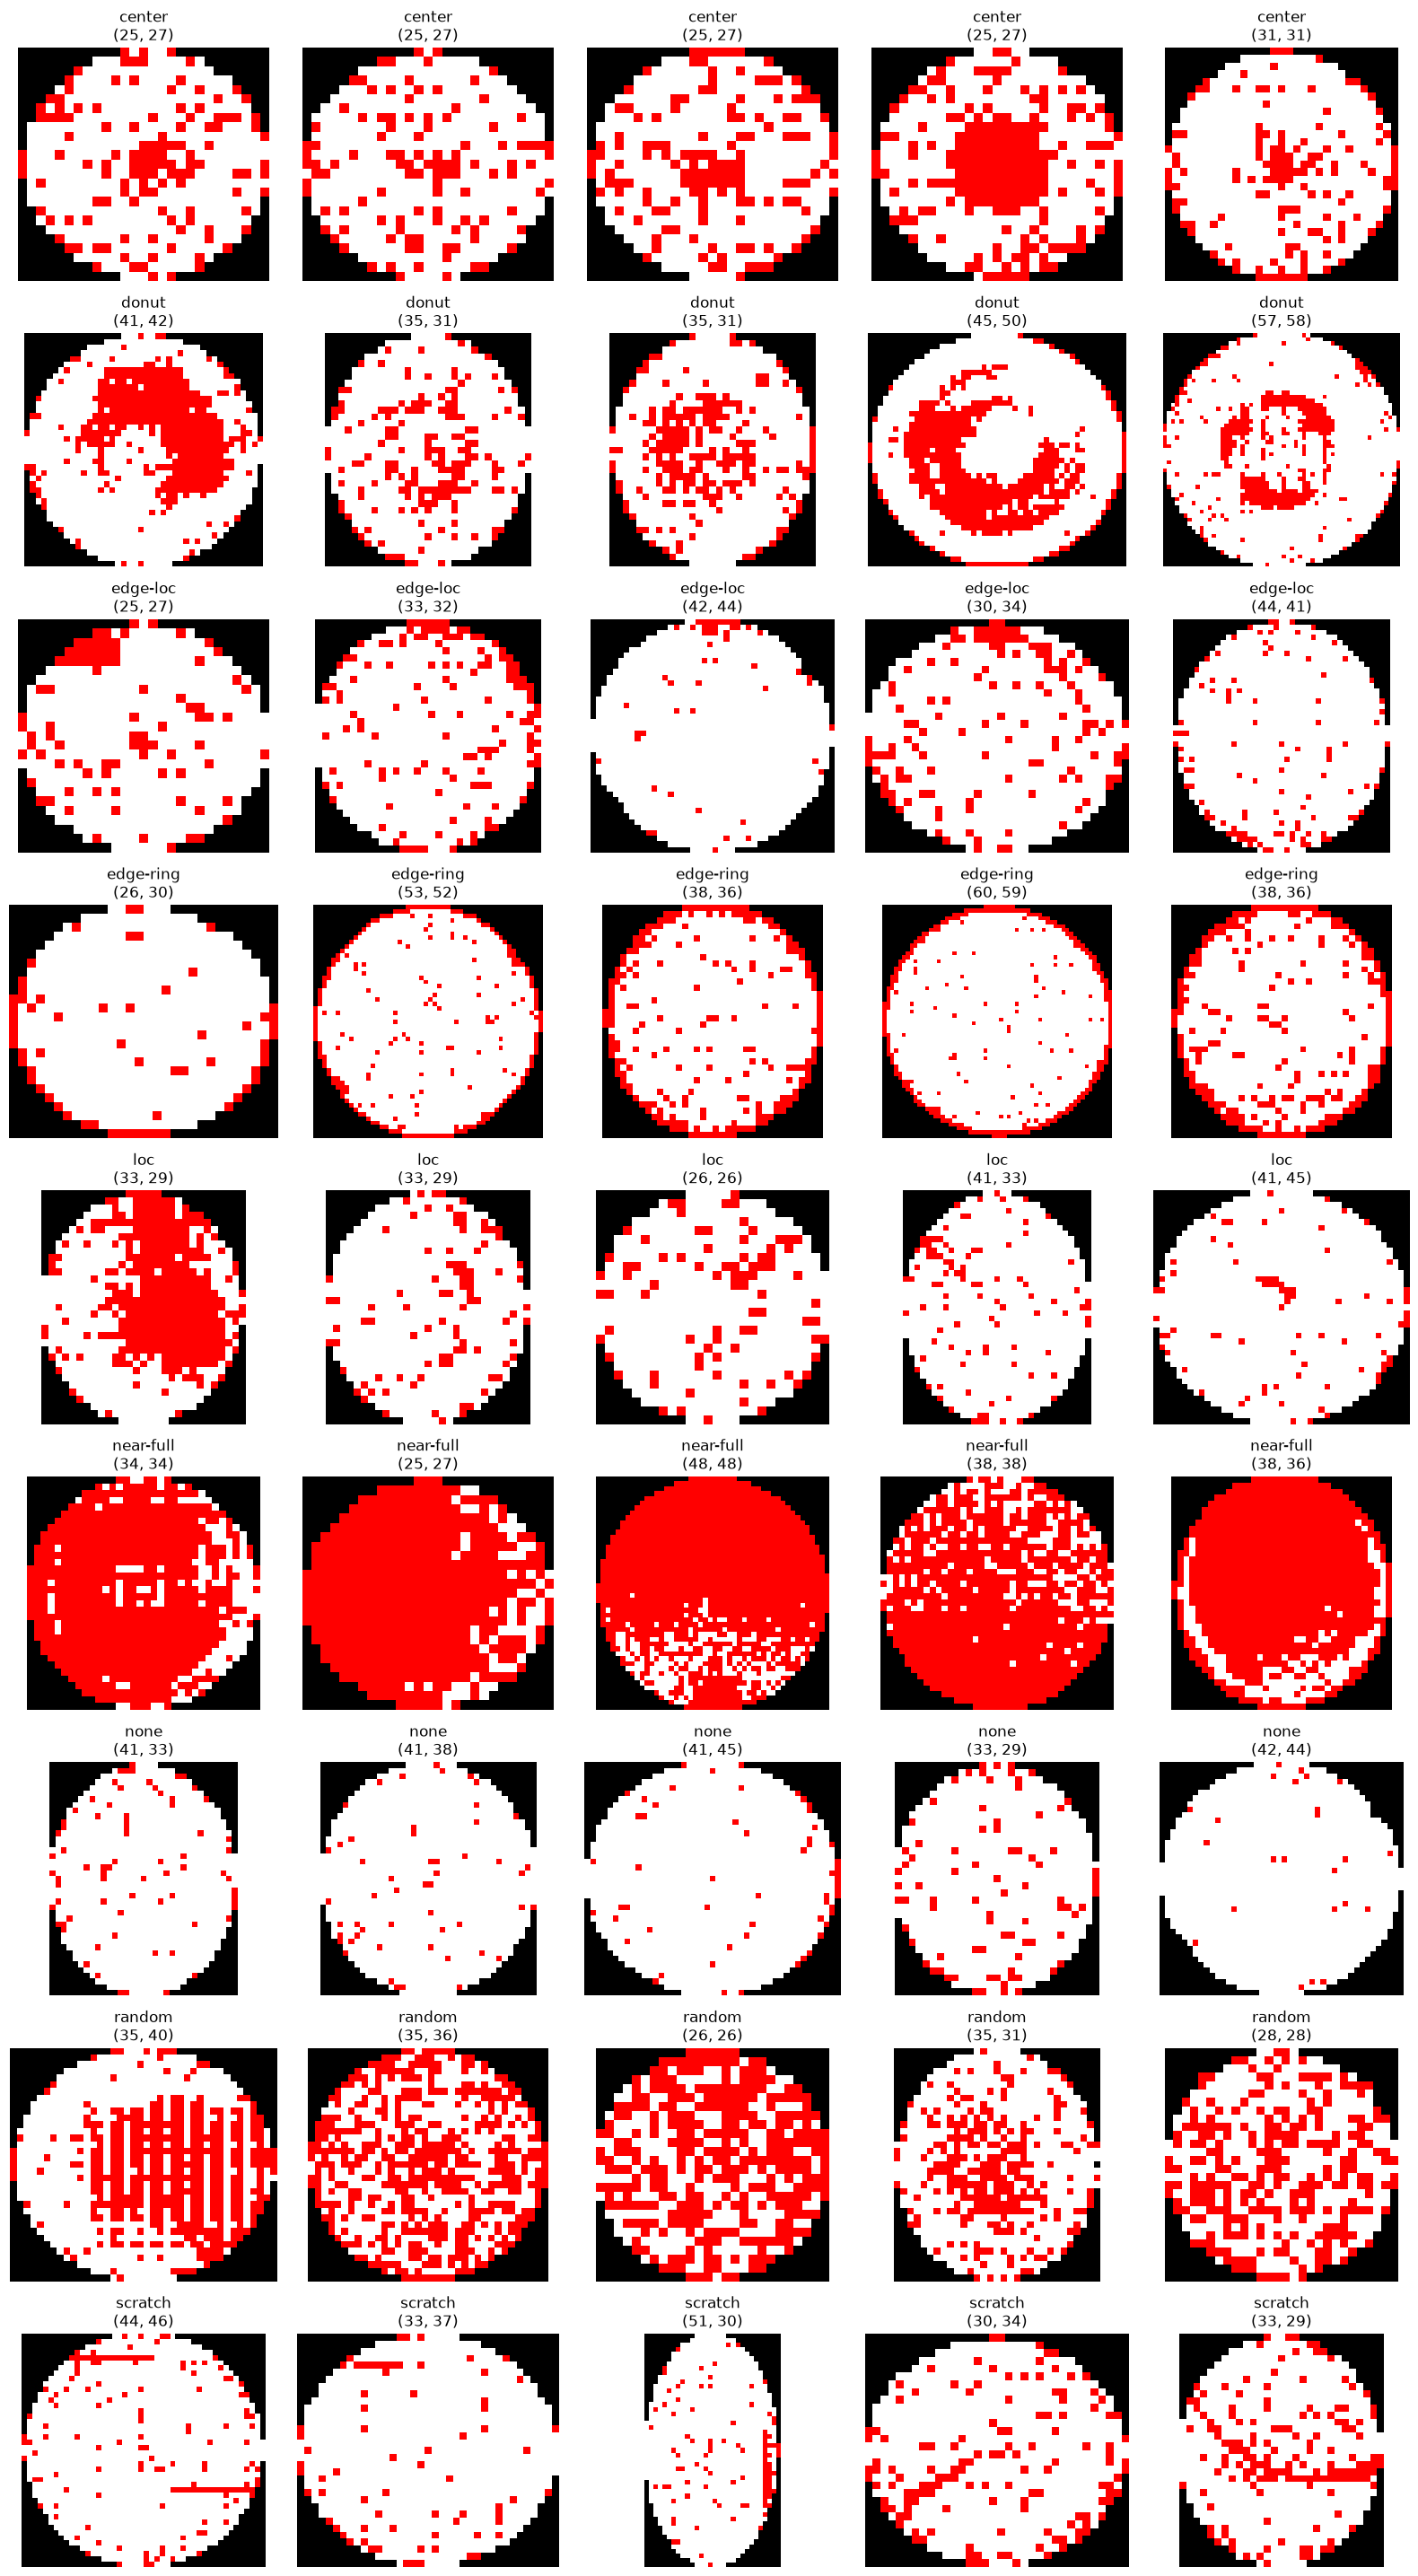

In [85]:
labeled_mask = labels.map(normalize_label) != "unlabeled"
labeled_types = sorted(labels[labeled_mask].unique())

n_rows, n_cols = len(labeled_types), 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))

for r, ft in enumerate(labeled_types):
    idxs = np.flatnonzero(labels == ft)
    chosen = np.random.choice(idxs, size=min(5, len(idxs)), replace=False)

    for c in range(n_cols):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        if c < len(chosen):
            row = df.iloc[chosen[c]]
            wm = np.asarray(row["waferMap"])
            ax.imshow(wm, cmap=WAFER_MAP_CMAP, norm=WAFER_MAP_NORM)
            ax.set_title(f"{ft}\n{wm.shape}")
            ax.axis("off")
        else:
            ax.axis("off")

plt.tight_layout()